## Classification

This notebook trains models to distinguish between human-authored and AI-generated DDR step charts.

We first do classification via feature engineering. We tell the model to look at specific aspects of the data that we create and tell it to learn from this (e.g. "look at hold ratio, look at timing variance") rather than by letting it discover the signal by itself. This is very interpretable for a human, but it also is us injecting our assumptions for what is valuable information.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

PROJECT_ROOT = Path('..').resolve()
REAL_DIR = PROJECT_ROOT / 'data' / 'real'
ARTIFICIAL_DIR = PROJECT_ROOT / 'data' / 'artificial'

SEED = 42
np.random.seed(SEED)

### 1. Load data

In [2]:
def load_all_charts(base_dir: Path, label: int) -> list[dict]:
    """Load all charts from a directory, assigning a label (0=human, 1=ai)."""
    charts = []
    for dataset in ['fraxtil', 'itg']:
        dataset_dir = base_dir / dataset
        if not dataset_dir.exists():
            continue
        for json_path in dataset_dir.glob('*.json'):
            with open(json_path, 'r') as f:
                data = json.load(f)
            song_name = data.get('song_name', json_path.stem)
            for diff_name, chart_data in data.get('charts', {}).items():
                steps = chart_data.get('steps', [])
                if len(steps) < 10:
                    continue
                charts.append({
                    'song_name': song_name,
                    'dataset': dataset,
                    'difficulty': diff_name,
                    'steps': steps,
                    'label': label
                })
    return charts

human_charts = load_all_charts(REAL_DIR, label=0)
ai_charts = load_all_charts(ARTIFICIAL_DIR, label=1)
all_charts = human_charts + ai_charts

display(Markdown(f"""
| Dataset | Charts |
|---------|--------|
| Human | {len(human_charts)} |
| AI | {len(ai_charts)} |
| **Total** | **{len(all_charts)}** |
"""))


| Dataset | Charts |
|---------|--------|
| Human | 1094 |
| AI | 1101 |
| **Total** | **2195** |


### 2. Feature extraction

We extract meaningful features:

- `steps_per_second`: Density, chart intensity
- `mean_delta`: Average time between steps
- `std_delta`: Timing variability, or rhythmic consistency
- `hold_ratio`: Fraction of steps that are holds
- `jump_ratio`: Fraction of steps that are jumps (2+ arrows)
- `unique_pattern_ratio`: Pattern vocabulary diversity
- `repeat_ratio`: How often consecutive steps repeat
- `arrow_entropy`: Balance across L/D/U/R arrows

In [3]:
def compute_entropy(probs: list[float]) -> float:
    probs = np.array([p for p in probs if p > 0])
    return -np.sum(probs * np.log2(probs))


def extract_features(chart: dict) -> dict | None:
    steps = chart['steps']
    if len(steps) < 10:
        return None
    
    times = np.array([s['time'] for s in steps])
    patterns = [s['step'] for s in steps]
    
    duration = times[-1] - times[0]
    delta_times = np.diff(times)
    delta_times = delta_times[delta_times > 0]
    
    if len(delta_times) == 0 or duration <= 0:
        return None
    
    n_steps = len(patterns)
    unique_patterns = len(set(patterns))
    
    holds = sum(1 for p in patterns if '2' in p or '3' in p)
    jumps = sum(1 for p in patterns if p.count('1') >= 2)
    repeats = sum(1 for i in range(1, len(patterns)) if patterns[i] == patterns[i-1])
    
    arrow_counts = [0, 0, 0, 0]  # L, D, U, R
    for p in patterns:
        for i, c in enumerate(p):
            if c in '123':
                arrow_counts[i] += 1
    total_arrows = sum(arrow_counts) or 1
    arrow_probs = [c / total_arrows for c in arrow_counts]
    
    return {
        'song_name': chart['song_name'],
        'dataset': chart['dataset'],
        'difficulty': chart['difficulty'],
        'label': chart['label'],
        'steps_per_second': n_steps / duration,
        'mean_delta': np.mean(delta_times),
        'std_delta': np.std(delta_times),
        'hold_ratio': holds / n_steps,
        'jump_ratio': jumps / n_steps,
        'unique_pattern_ratio': unique_patterns / n_steps,
        'repeat_ratio': repeats / (n_steps - 1) if n_steps > 1 else 0,
        'arrow_entropy': compute_entropy(arrow_probs),
    }

features = [extract_features(c) for c in all_charts]
features = [f for f in features if f is not None]
df = pd.DataFrame(features)

display(Markdown(f"Extracted features for {len(df)} charts:"))
df.head()

Extracted features for 2195 charts:

,song_name,dataset,difficulty,label,steps_per_second,mean_delta,std_delta,hold_ratio,jump_ratio,unique_pattern_ratio,repeat_ratio,arrow_entropy
0,Mosh Pit,fraxtil,Challenge,0,5.836735,0.171587,0.108981,0.226244,0.049774,0.048265,0.066465,1.997080
1,Mosh Pit,fraxtil,Hard,0,4.290310,0.233565,0.102429,0.090722,0.167010,0.049485,0.070248,1.999903
2,Mosh Pit,fraxtil,Medium,0,3.137821,0.319590,0.106877,0.011236,0.070225,0.033708,0.101408,1.995894
3,Mosh Pit,fraxtil,Easy,0,1.480769,0.679369,0.236647,0.119048,0.017857,0.101190,0.000000,1.979777
4,Mosh Pit,fraxtil,Beginner,0,0.872596,1.157699,0.375850,0.000000,0.010101,0.050505,0.183673,1.998846


In [4]:
FEATURE_COLS = [
    'steps_per_second',
    'mean_delta',
    'std_delta',
    'hold_ratio',
    'jump_ratio',
    'unique_pattern_ratio',
    'repeat_ratio',
    'arrow_entropy',
]

display(Markdown(f"Using **{len(FEATURE_COLS)}** features: `{'`, `'.join(FEATURE_COLS)}`"))

Using **8** features: `steps_per_second`, `mean_delta`, `std_delta`, `hold_ratio`, `jump_ratio`, `unique_pattern_ratio`, `repeat_ratio`, `arrow_entropy`

### 3. Train/test split

We split by *song*, not by chart. This prevents data leakage, since we don't want the model to recognize a song it's seen before.

In [5]:
songs = df['song_name'].unique()
np.random.shuffle(songs)

n_train = int(len(songs) * 0.8)
train_songs = set(songs[:n_train])
test_songs = set(songs[n_train:])

train_df = df[df['song_name'].isin(train_songs)].copy()
test_df = df[df['song_name'].isin(test_songs)].copy()

split_df = pd.DataFrame({
    'Split': ['Train', 'Test'],
    'Charts': [len(train_df), len(test_df)],
    'Songs': [len(train_songs), len(test_songs)],
    'Human': [(train_df['label'] == 0).sum(), (test_df['label'] == 0).sum()],
    'AI': [(train_df['label'] == 1).sum(), (test_df['label'] == 1).sum()]
})
display(split_df.set_index('Split'))

,Charts,Songs,Human,AI
Split,,,,
Train,1750,177,871,879
Test,445,45,223,222


In [6]:
X_train = train_df[FEATURE_COLS].values
y_train = train_df['label'].values
X_test = test_df[FEATURE_COLS].values
y_test = test_df['label'].values

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 4. Model training

We train three models:
1. *Logistic regression* — Linear, fully interpretable baseline
2. *Random forest* — Non-linear, feature importance, our main model
3. *Gradient boosting* — Often best performance, for comparison

In [7]:
models = {
    'Logistic regression': LogisticRegression(random_state=SEED, max_iter=1000),
    'Random forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=SEED),
    'Gradient boosting': GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=SEED),
}

results = {}

for name, model in models.items():
    X_tr = X_train_scaled if 'Logistic' in name else X_train
    X_te = X_test_scaled if 'Logistic' in name else X_test
    
    model.fit(X_tr, y_train)
    
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    
    results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba),
        'model': model,
        'y_pred': y_pred,
        'y_proba': y_proba,
    }

results_df = pd.DataFrame({
    name: {k: v for k, v in metrics.items() if k not in ['model', 'y_pred', 'y_proba']}
    for name, metrics in results.items()
}).T

display(Markdown("**Model Performance**"))
display(results_df.style.format('{:.3f}').background_gradient(cmap='Greens', axis=None))

**Model Performance**

,accuracy,precision,recall,f1,roc_auc
Logistic regression,0.829,0.790,0.896,0.840,0.903
Random forest,0.829,0.779,0.919,0.843,0.915
Gradient boosting,0.840,0.801,0.905,0.850,0.918


In [8]:
best_name = max(results.keys(), key=lambda k: results[k]['roc_auc'])
display(Markdown(f"Best model by ROC-AUC: *{best_name}* ({results[best_name]['roc_auc']:.3f})"))

Best model by ROC-AUC: *Gradient boosting* (0.918)

### 5. Cross-validation

Verify our results aren't due to a lucky train/test split.

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_results = []
for name in models:
    model_fresh = type(models[name])(**models[name].get_params())
    X = X_train_scaled if 'Logistic' in name else X_train
    scores = cross_val_score(model_fresh, X, y_train, cv=cv, scoring='roc_auc')
    cv_results.append({'Model': name, 'ROC-AUC': f"{scores.mean():.3f} ± {scores.std():.3f}"})

display(Markdown("5-Fold cross-validation (training set):"))
display(pd.DataFrame(cv_results).set_index('Model'))

5-Fold cross-validation (training set):

,ROC-AUC
Model,
Logistic regression,0.882 ± 0.007
Random forest,0.917 ± 0.006
Gradient boosting,0.917 ± 0.008


### 6. Feature importance

Which features matter most for distinguishing human vs AI charts?

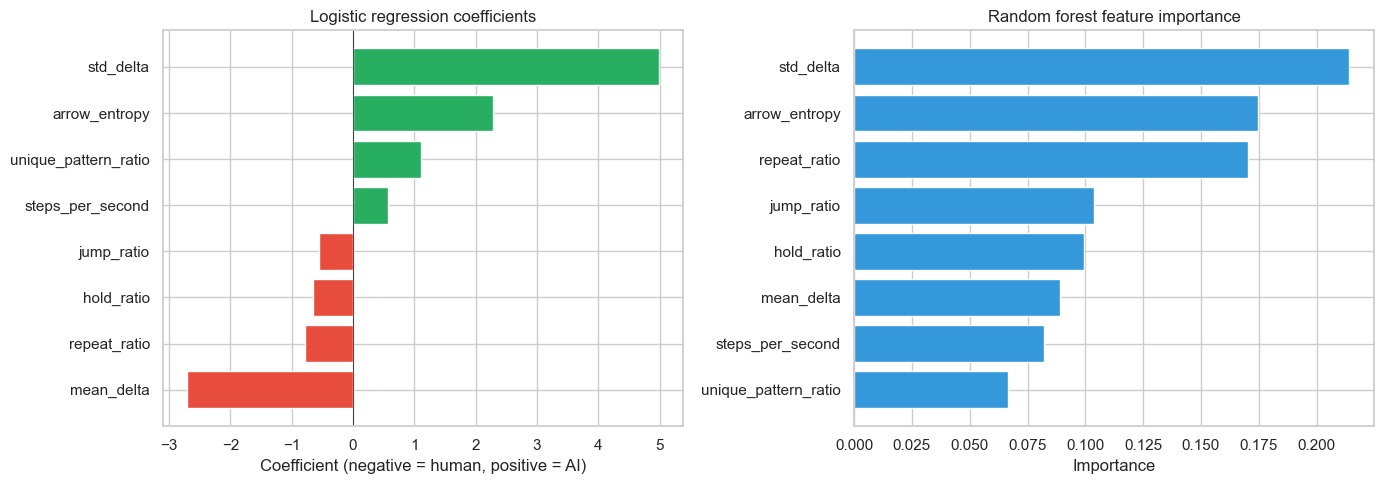

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

lr_model = results['Logistic regression']['model']
coef_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'coefficient': lr_model.coef_[0]
}).sort_values('coefficient')

colors = ['#e74c3c' if c < 0 else '#27ae60' for c in coef_df['coefficient']]
axes[0].barh(coef_df['feature'], coef_df['coefficient'], color=colors)
axes[0].axvline(x=0, color='black', linewidth=0.5)
axes[0].set_xlabel('Coefficient (negative = human, positive = AI)')
axes[0].set_title('Logistic regression coefficients')

rf_model = results['Random forest']['model']
importance_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': rf_model.feature_importances_
}).sort_values('importance')

axes[1].barh(importance_df['feature'], importance_df['importance'], color='#3498db')
axes[1].set_xlabel('Importance')
axes[1].set_title('Random forest feature importance')

plt.tight_layout()
plt.show()

### 7. Confusion matrix & ROC curve

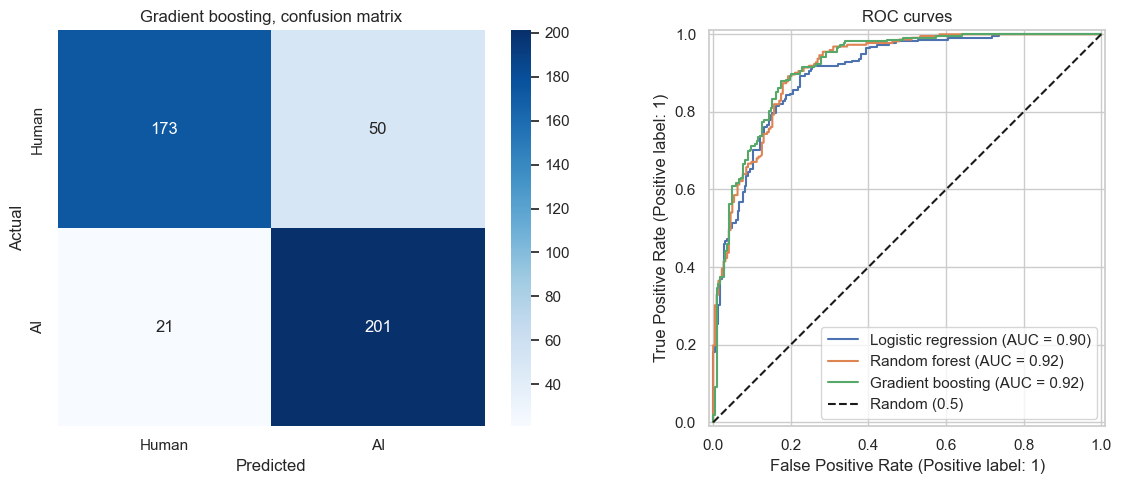

In [11]:
best_result = results[best_name]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y_test, best_result['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Human', 'AI'], yticklabels=['Human', 'AI'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title(f'{best_name}, confusion matrix')

for name, res in results.items():
    RocCurveDisplay.from_predictions(y_test, res['y_proba'], name=name, ax=axes[1])
axes[1].plot([0, 1], [0, 1], 'k--', label='Random (0.5)')
axes[1].set_title('ROC curves')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

In [12]:
display(Markdown(f"Classification report ({best_name}):"))

report = classification_report(y_test, best_result['y_pred'], target_names=['Human', 'AI'], output_dict=True)
report_df = pd.DataFrame(report).T
display(report_df.style.format('{:.3f}').background_gradient(cmap='Blues', subset=pd.IndexSlice[['Human', 'AI'], :]))

Classification report (Gradient boosting):

,precision,recall,f1-score,support
Human,0.892,0.776,0.830,223.000
AI,0.801,0.905,0.850,222.000
accuracy,0.840,0.840,0.840,0.840
macro avg,0.846,0.841,0.840,445.000
weighted avg,0.846,0.840,0.840,445.000


### 8. Error Analysis

Which charts does the model get wrong? Are there patterns?

In [13]:
test_df = test_df.copy()
test_df['predicted'] = best_result['y_pred']
test_df['confidence'] = best_result['y_proba']
test_df['correct'] = test_df['label'] == test_df['predicted']

errors = test_df[~test_df['correct']]

# Error summary
error_summary = pd.DataFrame({
    'Metric': ['Total errors', 'False positives (human → AI)', 'False negatives (AI → human)'],
    'Count': [len(errors), (errors['label'] == 0).sum(), (errors['label'] == 1).sum()],
    'Rate': [f"{len(errors)/len(test_df)*100:.1f}%", 
             f"{(errors['label'] == 0).sum()/len(errors)*100:.1f}%" if len(errors) > 0 else "0%",
             f"{(errors['label'] == 1).sum()/len(errors)*100:.1f}%" if len(errors) > 0 else "0%"]
})
display(Markdown("Error summary:"))
display(error_summary.set_index('Metric'))

error_by_diff = errors.groupby('difficulty').size()
total_by_diff = test_df.groupby('difficulty').size()
diff_data = []
for diff in ['Beginner', 'Easy', 'Medium', 'Hard', 'Challenge']:
    if diff in total_by_diff.index:
        err_count = error_by_diff.get(diff, 0)
        total = total_by_diff[diff]
        diff_data.append({'Difficulty': diff, 'Errors': err_count, 'Total': total, 'Error Rate': f"{err_count/total*100:.1f}%"})

display(Markdown("Errors by difficulty:"))
display(pd.DataFrame(diff_data).set_index('Difficulty'))

Error summary:

,Count,Rate
Metric,,
Total errors,71,16.0%
False positives (human → AI),50,70.4%
False negatives (AI → human),21,29.6%


Errors by difficulty:

,Errors,Total,Error Rate
Difficulty,,,
Beginner,4,87,4.6%
Easy,13,90,14.4%
Medium,14,90,15.6%
Hard,16,90,17.8%
Challenge,24,88,27.3%


### 9. Summary

In [15]:
display(Markdown(f"""
## Results

**Best model:** {best_name}

| Metric | Value |
|--------|-------|
| Accuracy | {best_result['accuracy']:.1%} |
| Precision | {best_result['precision']:.1%} |
| Recall | {best_result['recall']:.1%} |
| F1 Score | {best_result['f1']:.1%} |
| ROC-AUC | {best_result['roc_auc']:.3f} |
"""))


## Results

**Best model:** Gradient boosting

| Metric | Value |
|--------|-------|
| Accuracy | 84.0% |
| Precision | 80.1% |
| Recall | 90.5% |
| F1 Score | 85.0% |
| ROC-AUC | 0.918 |
